#### Proejto 1: Análise de Vendas Para LojaE-commerce com NumPy, Pandas e Matplotlib

##### 1 - Importação de Bibliotecas

In [1]:
# Instalação do pip
!pip install -q -U watermark

In [2]:
# Importação da biblioteca para manipulação de ddos em tabelas
import pandas as pd

In [3]:
# Importação da biblioteca NumPy para operações matemáticas e arrays
import numpy as np

In [29]:
# Importação da biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt

# Importação da biblioteca Seaborn para visualização estatística de dados
import seaborn as sns

# Importação da biblioteca random para geração de números aleatórios
import random

# Importação das classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta

# Comando do jupyter - notebook que permite exibir gráficos diretamente no notebook
%matplotlib inline

In [30]:
%reload_ext watermark

In [31]:
%watermark -a "Diniz"

Author: Diniz



In [32]:
%watermark --iversions

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.2.3
seaborn   : 0.13.2



In [8]:
# Instalar uma versão especifica do Pandas
!pip install -q pandas==2.3.1

##### 2 - Função para Geração de Dados

In [9]:
# Definição da função para gerar dados de vendas
def gera_dados(num_registros = 600):
    """
    Gera um DataFrame do Pandas com dados de vendas
    """

    # Mensagem inicial indicando a quantidade de registros a serem gerados
    print(f"\nIniciando a geração de {num_registros} registros de vendas...")

    # Dicionário com produtos, suas categorias e preços
    produtos ={
        'Laptop': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Acessórios', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hadware', 'preco': 600.00}
    }

    # Cria uma lista apenas com os nomes dos produtos
    lista_produtos = list(produtos.keys())

    # Dicionário com cidades e seus respectivos estados
    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro':'RJ', 'Belo Horizonte':'MG',
        'Porto Alegre':'RG', 'Salvador':'BA', 'Curitiva':'PR', 'Fortaleza':'CE'
    }

    # Criar um lista apenas com os nomes das cidades
    lista_cidades = list(cidades_estados.keys())

    # Lista que armazenará os registros de vendas
    dados_vendas = []

    # Define a data inicial dos pedidos
    data_inicial = datetime(2026, 1, 1)

    # Loop para gerar os registros de vendas 
    for i in range(num_registros):

        # Selecionar aleatoriamente um produto
        produto_nome = random.choice(lista_produtos)

        # Selecionar aleatoriamente uma cidade 
        cidade = random.choice(lista_cidades)

        # Gera uma quantidade de produtos vendidos entre 1 a 7
        quantidade = np.random.randint(1, 8)

        # Calcula a data do pedido a partir da data inicial
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        # Se o produto for Mouse ou Teclado, aplica desconto aleatório de até 10%
        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']

        # Adiciona um registro de venda à lista
        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]        
        })
    # Mensagem final indicando que a geração terminou
    print("Geração de dados concluída.\n")

    #Retorna os dados no formato de DataFrame
    return pd.DataFrame(dados_vendas)

##### 3 - Gerar, Carregar e Explorar os Dados

In [10]:
# Gerar os dados chamando a função da célula anterior
df_vendas = gera_dados(500)


Iniciando a geração de 500 registros de vendas...
Geração de dados concluída.



In [11]:
type(df_vendas)

pandas.core.frame.DataFrame

In [12]:
# Shape
df_vendas.shape

(500, 9)

In [13]:
# Exibe as 5 primeiras linhas DataFrame
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 18:00:00,Teclado Mecânico,Acessórios,522.65,1,128,São Paulo,SP
1,1001,2026-01-01 14:00:00,Mouse Vertical,Acessórios,230.59,6,114,Porto Alegre,RG
2,1002,2026-01-01 20:00:00,Monitor Ultrawide,Acessórios,2800.00,3,147,Rio de Janeiro,RJ
3,1003,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.00,4,115,Belo Horizonte,MG
4,1004,2026-01-01 13:00:00,SSD 1TB,Hadware,600.00,4,104,Porto Alegre,RG


In [14]:
# Exibe as 5 últimas linhas do DataFrame
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2026-04-10 14:00:00,Monitor Ultrawide,Acessórios,2800.00,3,122,Porto Alegre,RG
496,1496,2026-04-10 12:00:00,Headset 7.1,Acessórios,800.00,7,126,Rio de Janeiro,RJ
497,1497,2026-04-10 19:00:00,Monitor Ultrawide,Acessórios,2800.00,7,108,Salvador,BA
498,1498,2026-04-10 04:00:00,Placa de vídeo,Hardware,4500.00,5,101,Belo Horizonte,MG
499,1499,2026-04-10 22:00:00,Teclado Mecânico,Acessórios,531.63,4,135,Fortaleza,CE


In [15]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [16]:
# Resumo estatístico
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.000000,500.000000,500.00000
mean,1249.500000,2026-02-19 23:28:26.400000,2138.659380,4.104000,123.81200
min,1000.000000,2026-01-01 12:00:00,225.090000,1.000000,100.00000
25%,1124.750000,2026-01-26 03:30:00,586.992500,2.000000,111.00000
50%,1249.500000,2026-02-20 01:00:00,800.000000,4.000000,124.00000
75%,1374.250000,2026-03-16 20:00:00,2800.000000,6.000000,136.00000
max,1499.000000,2026-04-10 22:00:00,7500.000000,7.000000,149.00000
std,144.481833,NaN,2323.066964,2.018249,14.58211


In [17]:
# Tipos de dados
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

##### 4 - Limpeza, Pré-Processamento e Engenharia de Atributos

In [18]:
# Se a coluna 'Data_Pedido' não estiver como tipo datetime, precisamos fazer a conversão explicita
# A coluna pode ser usada para análise temporal
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [19]:
# Engenharia de atribuots
# Criando a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [20]:
# Engenharia de atributos
# Usando uma função lambda para criar um coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápido' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [21]:
# Exibe informações gerais sobre o DataFrame (tipos de dados , valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
 9   Faturamento     500 non-null    float64       
 10  Status_Entrega  500 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 43.1+ KB


In [22]:
# Exibe as 5 primeiras linhas novamente para ver as novas colunas
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 18:00:00,Teclado Mecânico,Acessórios,522.65,1,128,São Paulo,SP,522.65,Rápido
1,1001,2026-01-01 14:00:00,Mouse Vertical,Acessórios,230.59,6,114,Porto Alegre,RG,1383.54,Normal
2,1002,2026-01-01 20:00:00,Monitor Ultrawide,Acessórios,2800.00,3,147,Rio de Janeiro,RJ,8400.00,Rápido
3,1003,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.00,4,115,Belo Horizonte,MG,3200.00,Rápido
4,1004,2026-01-01 13:00:00,SSD 1TB,Hadware,600.00,4,104,Porto Alegre,RG,2400.00,Normal


##### 5 - Análise - 1: Top 10 Produtos Mais Vendidos com Pandas, NumPy e Matplotlib

In [24]:
# Agrupa por nome do produto, soma a quantidade e oredena pra encontrar os mais vendidos
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [25]:
# Exibe o resultado
top_10_produtos

Nome_Produto
Mouse Vertical       306
Headset 7.1          296
Monitor Ultrawide    267
Cadeira Gamer        266
SSD 1TB              260
Laptop               249
Placa de vídeo       207
Teclado Mecânico     201
Name: Quantidade, dtype: int64

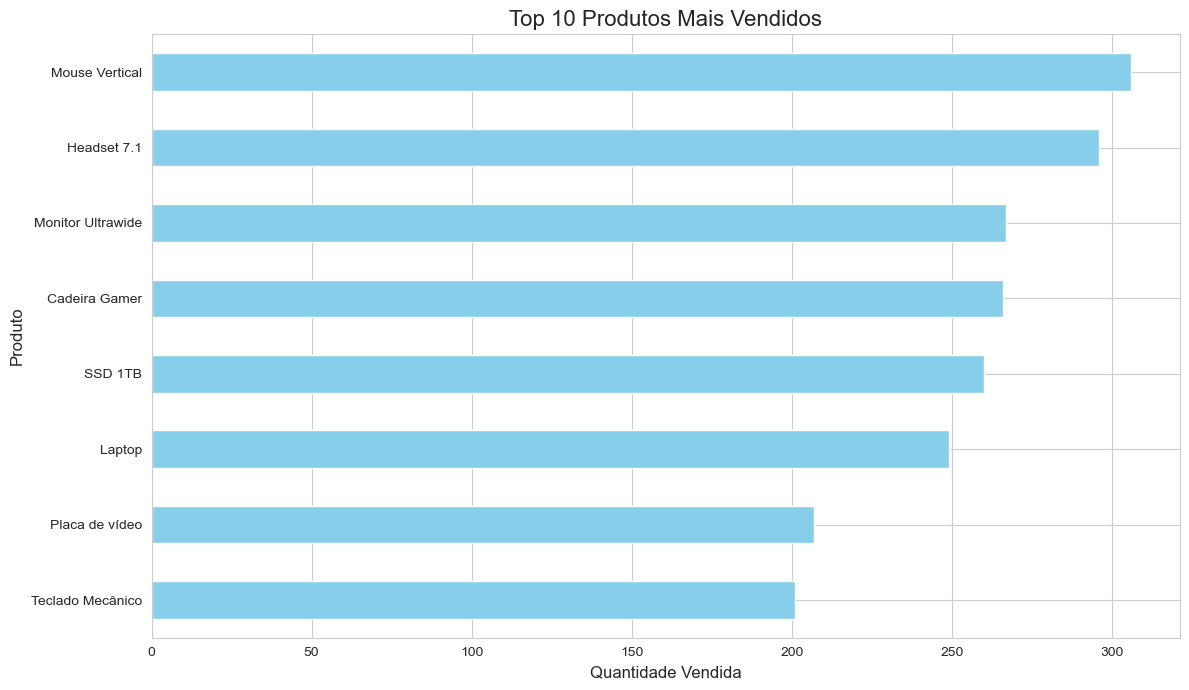

In [33]:
# Define um estilo para os gráficos
sns.set_style("whitegrid")

# Cria a figura e os eixos
plt.figure(figsize=(12, 7))

# Cria o gráfico títulos e labels
top_10_produtos.sort_values(ascending = True).plot(kind = 'barh' , color = 'skyblue')

# Adiciona títulos e labels
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()

##### 5 - Análise - 2: Faturamento Mensal com Pandas, NumPy e Matplotlib

In [34]:
# Cria uma coluna 'Mes' para facilitar o agrupamento mensal
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [39]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 18:00:00,Teclado Mecânico,Acessórios,522.65,1,128,São Paulo,SP,522.65,Rápido,2026-01
1,1001,2026-01-01 14:00:00,Mouse Vertical,Acessórios,230.59,6,114,Porto Alegre,RG,1383.54,Normal,2026-01
2,1002,2026-01-01 20:00:00,Monitor Ultrawide,Acessórios,2800.00,3,147,Rio de Janeiro,RJ,8400.00,Rápido,2026-01
3,1003,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.00,4,115,Belo Horizonte,MG,3200.00,Rápido,2026-01
4,1004,2026-01-01 13:00:00,SSD 1TB,Hadware,600.00,4,104,Porto Alegre,RG,2400.00,Normal,2026-01


In [35]:
# Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [38]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 18:00:00,Teclado Mecânico,Acessórios,522.65,1,128,São Paulo,SP,522.65,Rápido,2026-01
1,1001,2026-01-01 14:00:00,Mouse Vertical,Acessórios,230.59,6,114,Porto Alegre,RG,1383.54,Normal,2026-01
2,1002,2026-01-01 20:00:00,Monitor Ultrawide,Acessórios,2800.00,3,147,Rio de Janeiro,RJ,8400.00,Rápido,2026-01
3,1003,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.00,4,115,Belo Horizonte,MG,3200.00,Rápido,2026-01
4,1004,2026-01-01 13:00:00,SSD 1TB,Hadware,600.00,4,104,Porto Alegre,RG,2400.00,Normal,2026-01


In [36]:
# Converte o indice para string para facilitar a plotagem no gráfico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [40]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 18:00:00,Teclado Mecânico,Acessórios,522.65,1,128,São Paulo,SP,522.65,Rápido,2026-01
1,1001,2026-01-01 14:00:00,Mouse Vertical,Acessórios,230.59,6,114,Porto Alegre,RG,1383.54,Normal,2026-01
2,1002,2026-01-01 20:00:00,Monitor Ultrawide,Acessórios,2800.00,3,147,Rio de Janeiro,RJ,8400.00,Rápido,2026-01
3,1003,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.00,4,115,Belo Horizonte,MG,3200.00,Rápido,2026-01
4,1004,2026-01-01 13:00:00,SSD 1TB,Hadware,600.00,4,104,Porto Alegre,RG,2400.00,Normal,2026-01


In [41]:
# Faturamento para duas casa decimais
faturamento_mensal.map('R$ {:,.2f}'.format)

Mes
2026-01    R$ 1,327,965.75
2026-02    R$ 1,366,527.81
2026-03    R$ 1,283,067.19
2026-04      R$ 459,320.75
Name: Faturamento, dtype: object

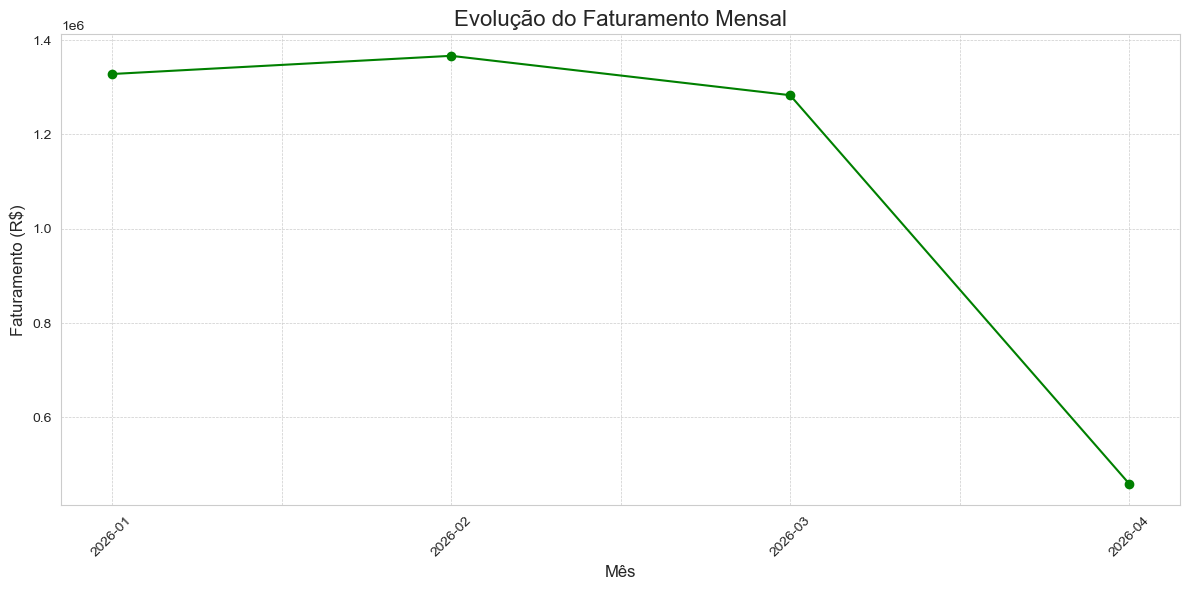

In [45]:
# Cria uma nova figura com tamanho de 12 por 6 polegadas
plt.figure(figsize = (12, 6))

# Plota os dados de faturamento mensal em formato de linha
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

# Define o título do gráfico com fonte de tamanho 16
plt.title('Evolução do Faturamento Mensal', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Mês', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Rotaciona os valores do eixo X em 45 graus para melhor visualização
plt.xticks(rotation = 45)

# Adiciona uma grade com estilo tracejando e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

# Ajusta automaticamente os elementos para evitar sobreposção
plt.tight_layout()

# Exibe o gráfico
plt.show()